# Synthetic Medical Image Generation: cGAN vs cVAE
**Dataset:** PneumoniaMNIST (28×28 grayscale chest X-rays, binary: Normal vs Pneumonia)

**Goal:** Train two generative models and compare their synthetic outputs:
- **Conditional GAN (cGAN)** — adversarial training, sharp outputs
- **Conditional VAE (cVAE)** — probabilistic encoding, stable training

---
## Table of Contents
1. Setup & Imports
2. Data Loading & EDA
3. Conditional GAN
4. Conditional VAE
5. Side-by-side Comparison

---
## Section 1: Setup & Imports

In [1]:
# Install required libraries (run once)
# medmnist   : provides the PneumoniaMNIST dataset
# torch      : deep learning framework (models, autograd, optimizers)
# torchvision: image transforms (ToTensor, Normalize)
# matplotlib : plotting images and loss curves
# numpy      : numerical operations (array math, covariance)
# scipy      : matrix square root for FID score computation
!pip install medmnist torch torchvision matplotlib numpy scipy --quiet

In [2]:
import torch                              # Core PyTorch: tensors, autograd
import torch.nn as nn                     # Neural network building blocks (Linear, Conv2d, etc.)
import torch.optim as optim               # Optimizers (Adam)
import torchvision.transforms as transforms  # Image preprocessing pipelines
from torch.utils.data import DataLoader   # Batches & shuffles the dataset during training

import medmnist                           # MedMNIST benchmark datasets
from medmnist import PneumoniaMNIST       # Specifically the chest X-ray pneumonia dataset

import numpy as np                        # Array operations, covariance matrices
import matplotlib.pyplot as plt           # Visualization
from scipy import linalg                  # Matrix square root used in FID calculation

# ── Reproducibility ──────────────────────────────────────────────────────────
# Setting seeds ensures that random operations (weight init, noise sampling,
# data shuffling) produce the same result every run — critical for debugging.
SEED = 42
torch.manual_seed(SEED)   # Seeds PyTorch's random number generator
np.random.seed(SEED)      # Seeds NumPy's random number generator

# ── Device ───────────────────────────────────────────────────────────────────
# Use GPU if available — training on GPU is typically 10-50x faster.
# Falls back to CPU if no CUDA-capable GPU is detected.
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
print(f'MedMNIST version: {medmnist.__version__}')

Using device: cpu
MedMNIST version: 3.0.2


---
## Section 2: Data Loading & EDA

In [37]:
# ── Transforms ───────────────────────────────────────────────────────────────
# GAN uses Tanh output → normalize images to [-1, 1]
# VAE uses Sigmoid output → keep images in [0, 1]

transform_gan = transforms.Compose([
    # Step 1: Convert PIL image (H×W, uint8 0–255) to float tensor (C×H×W, 0.0–1.0)
    transforms.ToTensor(),
    # Step 2: Shift range from [0,1] → [-1,1]
    # Formula: output = (input - mean) / std = (input - 0.5) / 0.5
    # When input=0.0 → output=-1.0; when input=1.0 → output=+1.0
    transforms.Normalize(mean=[0.5], std=[0.5])
])

transform_vae = transforms.Compose([
    # Only need ToTensor — Sigmoid output already spans [0,1]
    transforms.ToTensor()
])

# ── Load datasets ─────────────────────────────────────────────────────────────
# split='train' : use the official training partition (4,708 samples)
# transform     : apply the preprocessing pipeline defined above
# download=True : auto-download from MedMNIST servers if not already cached
train_gan = PneumoniaMNIST(split='train', transform=transform_gan, download=True)
train_vae = PneumoniaMNIST(split='train', transform=transform_vae, download=True)

# Both datasets return a tuple: (image_tensor, label_tensor)
# image shape: (1, 28, 28) — 1 grayscale channel, 28×28 pixels
# label shape: (1,)        — single integer: 0=Normal, 1=Pneumonia
# The underlying images are identical — only the pixel value range differs
# due to the different transforms applied at load time.

print('=== GAN Dataset (normalized to [-1, 1]) ===')
print(f'Train size : {len(train_gan)}')
print(f'Image shape: {train_gan[0][0].shape}')
print(f'Label shape: {train_gan[0][1].shape}')
print(f'Pixel range: [{train_gan[0][0].min():.3f}, {train_gan[0][0].max():.3f}]')

print()
print('=== VAE Dataset (normalized to [0, 1]) ===')
print(f'Train size : {len(train_vae)}')
print(f'Image shape: {train_vae[0][0].shape}')
print(f'Label shape: {train_vae[0][1].shape}')
print(f'Pixel range: [{train_vae[0][0].min():.3f}, {train_vae[0][0].max():.3f}]')

Using downloaded and verified file: /Users/sunetnanta/.medmnist/pneumoniamnist.npz
Using downloaded and verified file: /Users/sunetnanta/.medmnist/pneumoniamnist.npz
=== GAN Dataset (normalized to [-1, 1]) ===
Train size : 4708
Image shape: torch.Size([1, 28, 28])
Label shape: (1,)
Pixel range: [-1.000, 0.765]

=== VAE Dataset (normalized to [0, 1]) ===
Train size : 4708
Image shape: torch.Size([1, 28, 28])
Label shape: (1,)
Pixel range: [0.000, 0.882]


/var/folders/5d/k7gxx1wn7y156f92kp762f700000gn/T/ipykernel_94944/4198621379.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_all  = [int(train_gan[i][1]) for i in range(len(train_gan))] # train_gan has two parameters (image, label) so we [1] to get the labels


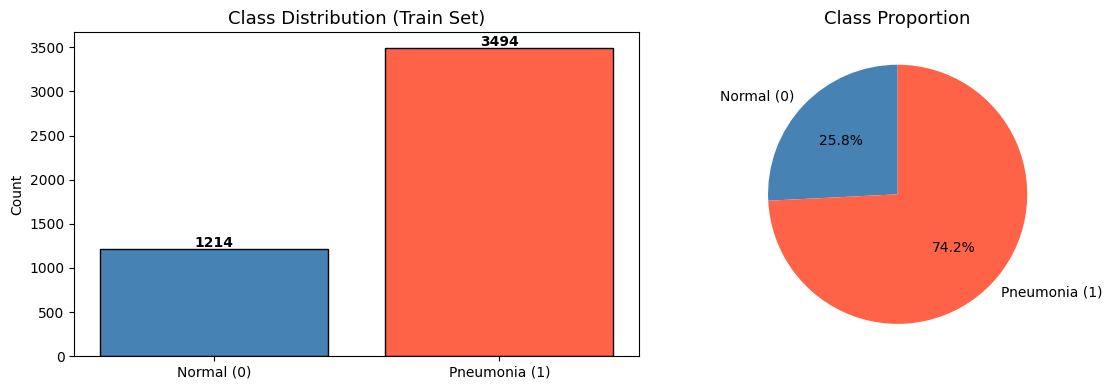

Normal: 1214 | Pneumonia: 3494 | Ratio: 2.88:1


In [5]:
# ── Class Distribution ────────────────────────────────────────────────────────
# Extract the integer label (0 or 1) for every sample in the training set.
# train_gan[i][1] is a tensor like tensor([1]), so int() unwraps it to 1.
labels_all  = [int(train_gan[i][1]) for i in range(len(train_gan))] # train_gan has two parameters (image, label) so we [1] to get the labels
class_names = ['Normal (0)', 'Pneumonia (1)']

# Count how many samples belong to each class
counts = [labels_all.count(0), labels_all.count(1)]

# Create a 1-row, 2-column figure: left=bar chart, right=pie chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: bar chart ──
axes[0].bar(class_names, counts, color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution (Train Set)', fontsize=13)
axes[0].set_ylabel('Count')
# Annotate each bar with its count value, placed slightly above the bar top
for i, v in enumerate(counts):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# ── Right: pie chart ──
# autopct='%1.1f%%' displays percentage with 1 decimal place inside each slice
axes[1].pie(counts, labels=class_names, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Class Proportion', fontsize=13)

plt.tight_layout()  # Prevent subplot labels from overlapping
plt.show()

# Print the imbalance ratio — important because a 3:1 imbalance means a naive
# model can get 75% accuracy by always predicting Pneumonia. That's why we
# may want to generate synthetic Normal images to balance the dataset.
print(f'Normal: {counts[0]} | Pneumonia: {counts[1]} | Ratio: {counts[1]/counts[0]:.2f}:1')

/var/folders/5d/k7gxx1wn7y156f92kp762f700000gn/T/ipykernel_94944/2088173236.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if len(normal_imgs) < n_per_class and int(label) == 0:
/var/folders/5d/k7gxx1wn7y156f92kp762f700000gn/T/ipykernel_94944/2088173236.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  elif len(pneumonia_imgs) < n_per_class and int(label) == 1:


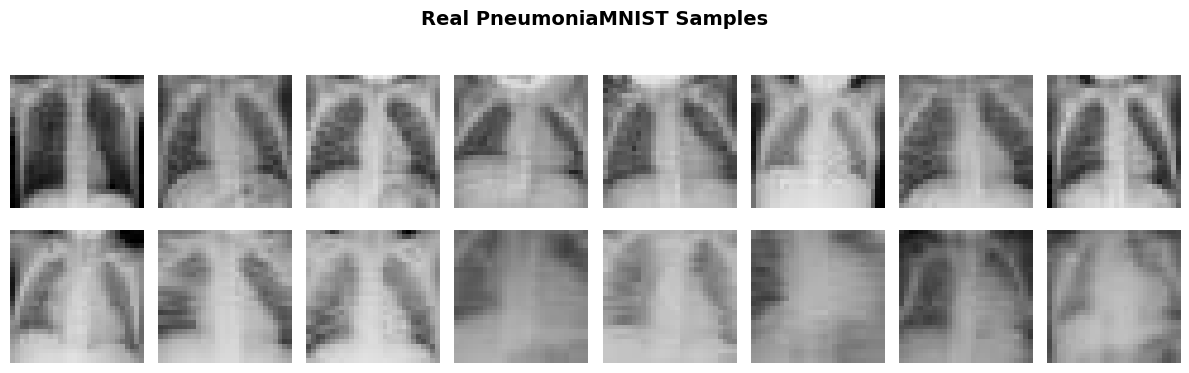

In [ ]:
def show_samples(dataset, title, n_per_class=8): #8 is default value
    """Display n_per_class samples from each class side by side."""
    # Collect images separately per class by iterating the dataset
    # Just for quick visual inspection using the first 8 representative of the dataset
    normal_imgs, pneumonia_imgs = [], []
    for img, label in dataset:
        # int(label) converts tensor([0]) → 0 for comparison
        if len(normal_imgs) < n_per_class and int(label) == 0:
            normal_imgs.append(img)
        elif len(pneumonia_imgs) < n_per_class and int(label) == 1:
            pneumonia_imgs.append(img)
        # Stop early once we have enough of both — no need to scan entire dataset
        if len(normal_imgs) == n_per_class and len(pneumonia_imgs) == n_per_class:
            break

    # 2 rows (Normal, Pneumonia) × n_per_class columns
    fig, axes = plt.subplots(2, n_per_class, figsize=(n_per_class * 1.5, 4))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i in range(n_per_class):
        # .squeeze() removes the channel dimension: (1,28,28) → (28,28) for imshow
        # * 0.5 + 0.5 reverses the GAN normalization: [-1,1] → [0,1] for display
        axes[0, i].imshow(normal_imgs[i].squeeze() * 0.5 + 0.5, cmap='gray', vmin=0, vmax=1)
        axes[0, i].axis('off')   # Hide axis ticks and borders
        axes[1, i].imshow(pneumonia_imgs[i].squeeze() * 0.5 + 0.5, cmap='gray', vmin=0, vmax=1)
        axes[1, i].axis('off')

    # Label the rows on the leftmost column only
    axes[0, 0].set_ylabel('Normal',    color='steelblue', fontsize=10)
    axes[1, 0].set_ylabel('Pneumonia', color='tomato',    fontsize=10)
    plt.tight_layout()
    plt.show()

show_samples(train_gan, 'Real PneumoniaMNIST Samples')

---
## Section 3: Conditional GAN (cGAN)

### How it works
- **Generator** takes random noise `z` + a class label → produces a fake image
- **Discriminator** takes an image + a class label → predicts Real or Fake
- They compete: G tries to fool D, D tries to catch G
- The *conditional* part means both G and D receive the class label, so G learns to generate class-specific images

```
noise (z) ──┐
             ├──→ Generator ──→ fake image ──┐
label    ──┘                                 ├──→ Discriminator ──→ Real/Fake
                          real image ────────┘
                          label      ────────┘
```

In [ ]:
GAN_CONFIG = {
    # latent_dim: length of the random noise vector z fed to the Generator.
    # Higher = more capacity to represent variation, but harder to train.
    # 100 is a standard choice from the original DCGAN paper.
    'latent_dim'  : 100, # noise z for GAN/ VAE latent space in a sense

    # embed_dim: how many numbers represent each class label after embedding. 
    # nn.Embedding maps an integer (0 or 1) to a learned dense vector of this size. --> This number would be higher if there were more class (2 here)
    # Prior to this we have 0 or 1 , AKA scalar label input
    # This embed_dim assign 16 numbers (vectors) instead of 0 or 1 to allow the network to "learn" with a scaled weight (and fine-tunes it)
    'embed_dim'   : 16, # 16 number starts at random -> updated by the optimiser -> turns into a somewhat descriptor of the class' label

    # n_classes: number of distinct classes the GAN is conditioned on.
    # Here: 0=Normal, 1=Pneumonia
    'n_classes'   : 2, # Fixed

    'img_channels': 1,   # Grayscale — only 1 color channel
    'img_size'    : 28,  # 28×28 pixels; Fixed in the MNIST dataset

    # batch_size: how many images are processed in one forward/backward pass.
    # Larger = more stable gradient estimates but more memory usage.
    'batch_size'  : 128,

    # lr: learning rate — step size for gradient updates.
    # 0.0002 is the standard for DCGAN-style architectures.
    'lr'          : 0.0002,

    # betas: Adam optimizer momentum parameters (β1, β2).
    # β1=0.5 (instead of the default 0.9) is recommended for GANs — it makes
    # the optimizer less "sticky" and more responsive to gradient direction changes,
    # which helps when G and D loss oscillate during adversarial training.
    'betas'       : (0.5, 0.999),

    'epochs'      : 50, #50 pass through the data is a shuffled order

    # label_smooth: instead of using 1.0 for real image targets, use 0.9.
    # This prevents the Discriminator from becoming overconfident (saturating
    # the sigmoid to 1.0), which would give the Generator zero gradient signal.
    'label_smooth': 0.1,
}

In [ ]:
class Generator(nn.Module):
    """
    cGAN Generator.
    Input : noise z (latent_dim,) + class label (integer)
    Output: fake image (1, 28, 28) with pixel values in [-1, 1] via Tanh

    Process: embed label → concat with noise → FC (Fully Connected/ Dense) layer → reshape to 3D feature map
             → ConvTranspose2d to upsample from 7×7 up to 28×28
    """
    def __init__(self, cfg):
        super().__init__()  # Initialize the parent nn.Module
        self.cfg = cfg

        # nn.Embedding(num_embeddings, embedding_dim):
        # Learns a lookup table: integer label → dense vector of size embed_dim.
        # This is how we inject class information into the generator.
        # e.g., label 0 (Normal) → some learned 16-dim vector
        #        label 1 (Pneumonia) → a different learned 16-dim vector
        self.label_emb = nn.Embedding(cfg['n_classes'], cfg['embed_dim'])

        # Total input to FC layer = noise vector + label embedding
        # Precalculates the size of the combined input vector fc_input (required for the FC layer)
        fc_input = cfg['latent_dim'] + cfg['embed_dim']  # 100 + 16 = 116

        # FC block: maps the 1D combined vector → 1D vector that will be reshaped
        # into a 3D feature map (128 channels × 7×7 spatial) to get an image
        # 7x7 doubles each time as we parse through a convtranspose layer -> with 2 layers -> 28x28 final target image size
        # basically vector -> image
        self.fc = nn.Sequential(
            # Projects 116-dim → 128*7*7 = 6272-dim
            nn.Linear(fc_input, 128 * 7 * 7),
            # BatchNorm1d normalizes activations across the batch at each feature position.
            # Stabilizes training by keeping activations in a consistent range.
            nn.BatchNorm1d(128 * 7 * 7),
            # ReLU: non-linearity. inplace=True modifies tensor in-place to save memory.
            nn.ReLU(inplace=True)
        )

        # Convolutional upsampling block: progressively increases spatial resolution
        self.conv = nn.Sequential(
            # ConvTranspose2d ("deconvolution"): the reverse of a Conv2d.
            # It increases spatial size. With kernel=4, stride=2, pad=1:
            # output_size = (input_size - 1)*stride - 2*padding + kernel = (7-1)*2 - 2 + 4 = 14
            # So: 7×7 → 14×14, and channels: 128 → 64
            ### 1st layer ###
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), #from (128, 7, 7) to (64, 14, 14) ~12,544
            nn.BatchNorm2d(64),   # Normalize across batch per spatial location
            nn.ReLU(inplace=True),
            # Reasoning: (early layers) small spatial -> higher channels needed to capture image *COARSE STRUCTURE*

            ### 2nd layer ###
            # Second upsample: 14×14 → 28×28, channels: 64 → 32
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), #from (64, 14, 14) to (32, 28, 28) ~25,088
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            # Reasoning: (later layers) large spatial to represent fine details -> need lower channels *PRECISE DETAILS*

            ### Final grayscale output ###
            # Final Conv2d (stride=1, no size change): 32 → 1 channel (grayscale).
            # padding=1 with kernel=3 keeps spatial size at 28×28.
            nn.Conv2d(32, cfg['img_channels'], kernel_size=3, stride=1, padding=1), #from (32, 28, 28) to (1, 28, 28)

            # Tanh squashes output to [-1, 1], matching the GAN-normalized training data.
            # This is critical — if output range doesn't match target range, BCE loss
            # in the discriminator gives meaningless gradients.
            nn.Tanh()
        )

    # Actually running the convolution
    def forward(self, z, labels):
        # Look up label embedding: integer → dense vector
        # z shape: (B, 100), emb shape: (B, 16) ; B = batch size
        emb = self.label_emb(labels)

        # Concatenate along feature dimension → (B, 116)
        # Add noise z and label together
        x = torch.cat([z, emb], dim=1)

        # FC layers → (B, 128*7*7 = 6272)
        x = self.fc(x)

        # Reshape 1D feature vector into 3D feature map for ConvTranspose
        # -1 means: infer this dimension from the other dimensions (= batch size)
        x = x.view(-1, 128, 7, 7)   # (B, 128, 7, 7)

        # Upsample through ConvTranspose layers → (B, 1, 28, 28)
        return self.conv(x)

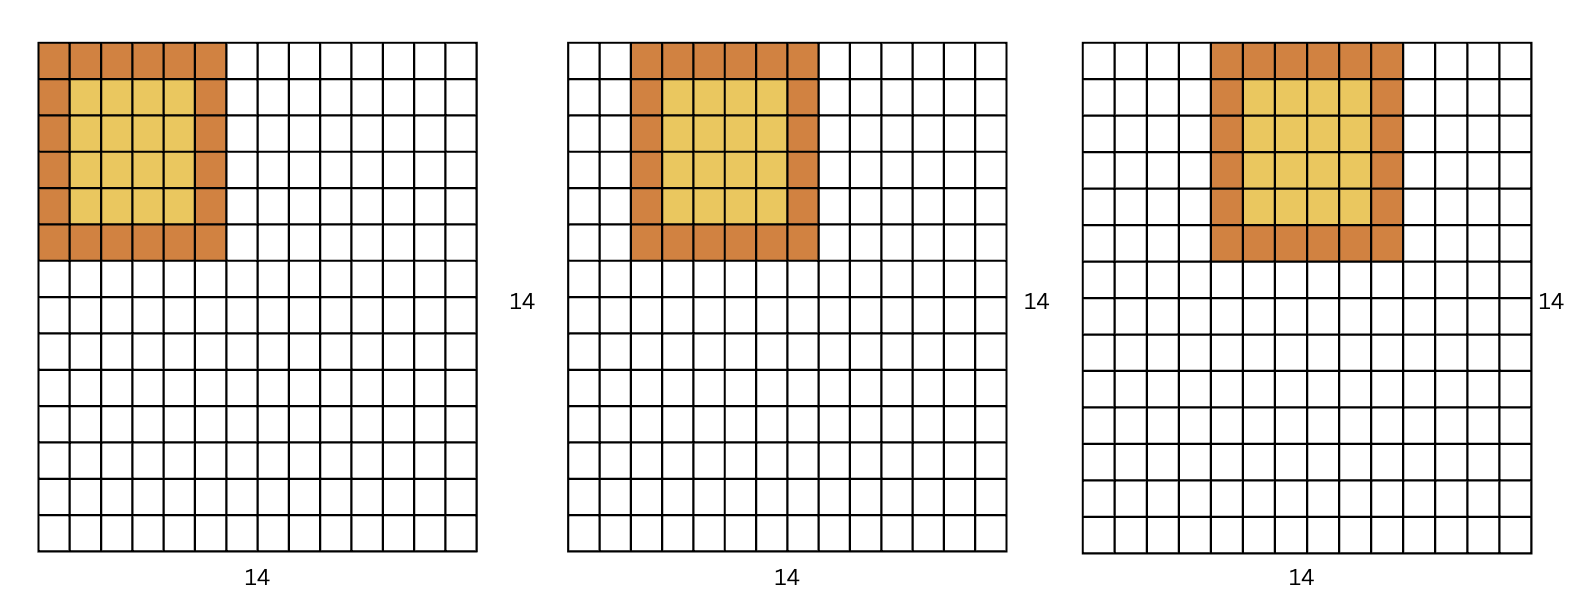

In [ ]:
class Discriminator(nn.Module):
    """
    cGAN Discriminator.
    Input : image (1, 28, 28) + class label (integer)
    Output: scalar in [0,1] — probability of the image being real

    The label is embedded and projected to a full 28×28 spatial map,
    then concatenated as a second image channel. This way the discriminator
    can detect both "does this look like a real X-ray?" AND
    "does this look like the claimed class?" simultaneously.
    """ 
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        # Project the label into a full spatial map matching the image size.
        # embed_dim = img_size * img_size = 28*28 = 784
        # So label 0 maps to a learned 784-dim vector that will be reshaped to (1,28,28).
        # This spatial label map is then treated as a second input channel alongside
        # the image, allowing convolutional layers to reason spatially about class.
        self.label_emb = nn.Embedding(cfg['n_classes'], cfg['img_size'] * cfg['img_size'])

        # Conv feature extractor. Input has 2 channels: image + label map.
        # Uses LeakyReLU (not ReLU) — standard for discriminators because it allows
        # small negative gradients, preventing "dead neurons" which would stop
        # the discriminator from learning.
        self.conv = nn.Sequential(
            # (B, 2, 28, 28) → (B, 64, 13, 13)
            # From output_size = floor(((input + 2×padding - kernel) / stride) + 1)
            # kernel=4, stride=2, pad=1: output = floor((28 + 2*1 - 4)/2 + 1) = 14
            # (slight asymmetry due to floor) → gives 13 with these exact params
            nn.Conv2d(2, 64, kernel_size=4, stride=2, padding=1),
            # LeakyReLU(0.2): passes positive values unchanged, scales negatives by 0.2
            nn.LeakyReLU(0.2, inplace=True),

            # (B, 64, 13, 13) → (B, 128, 6, 6)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),  # Normalize per channel across batch & spatial dims
            nn.LeakyReLU(0.2, inplace=True),

            # (B, 128, 6, 6) → (B, 256, 3, 3)
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )

        self.fc = nn.Sequential(
            # Flatten (B, 256, 3, 3) → (B, 256*3*3 = 2304)
            nn.Flatten(),
            # Collapse 2304 features down to a single score
            nn.Linear(256 * 3 * 3, 1),
            # Sigmoid maps the raw score to a probability in [0,1]:
            # 0 = definitely fake, 1 = definitely real
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        # Embed label → flatten 784-dim vector → reshape to (B, 1, 28, 28)
        # This creates a spatial "label image" matching the input image dimensions
        label_map = self.label_emb(labels)  # (B, 784)
        label_map = label_map.view(-1, 1, self.cfg['img_size'], self.cfg['img_size'])  # (B, 1, 28, 28)

        # Stack image and label map along the channel dimension → (B, 2, 28, 28)
        # Now every conv filter sees both pixel values AND class information
        x = torch.cat([img, label_map], dim=1)

        x = self.conv(x)   # Extract features: (B, 256, 3, 3)
        return self.fc(x)  # Classify: (B, 1) in [0,1]

Generator:      noise vector (116,) → image (28×28)
                small → big  =  EXPAND  =  ConvTranspose2d
** Expand and synthesise **

ConvTranspose2d (Deconvolution) does the reverse and grows spatial size:
noise → (128, 7, 7) → (64, 14, 14) → (32, 28, 28) → image

----------------------------------------

Discriminator:  image (28×28) → single number (real/fake probability)
                big → small  =  COMPRESS  =  Conv2d
** Compress and classify **

Conv2d slides a filter over the input and shrinks spatial size:
(2, 28, 28) → (64, 14, 14) → (128, 6, 6) → (256, 3, 3) → single score


In [ ]:
# Instantiate Generator and Discriminator and move them to the selected device
# (CPU or GPU). .to(DEVICE) copies all model parameters to that device.
G = Generator(GAN_CONFIG).to(DEVICE)
D = Discriminator(GAN_CONFIG).to(DEVICE)

def weights_init(m):
    """
    Custom weight initialization for GAN layers.
    Applied via model.apply(weights_init) which calls this on every sub-module.

    Why not default initialization?
    PyTorch defaults (Kaiming/Xavier) work well for standard classifiers,
    but GANs benefit from smaller initial weights (std=0.02) to keep the
    adversarial dynamics stable at the start of training.
    """
    classname = m.__class__.__name__
    if 'Conv' in classname:
        # Normal distribution with mean=0, std=0.02 for all Conv weight matrices
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        # BatchNorm weights start at 1 (scale) with small noise; bias starts at 0
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# .apply() recursively visits every layer and calls weights_init on it
G.apply(weights_init)
D.apply(weights_init)

# Two separate Adam optimizers — one per model.
# They must be separate because G and D are updated at different times:
# - opt_D.step() only updates D's weights
# - opt_G.step() only updates G's weights
# If they shared one optimizer, stepping would incorrectly update both.
opt_G = optim.Adam(G.parameters(), lr=GAN_CONFIG['lr'], betas=GAN_CONFIG['betas'])
opt_D = optim.Adam(D.parameters(), lr=GAN_CONFIG['lr'], betas=GAN_CONFIG['betas'])

# BCELoss = Binary Cross Entropy Loss.
# For a prediction p and target t: loss = -(t*log(p) + (1-t)*log(1-p))
# Use 0-1 raw possibility score from the discriminator to compute the loss func of the model (how wrong the probability is)
criterion = nn.BCELoss()
# The smaller the loss value means the discriminator was more accurate (real=real, fake=fake)

# DataLoader wraps the dataset to:
# - yield batches of size batch_size
# - shuffle=True: randomize order each epoch (prevents memorizing order)
# - num_workers=2: use 2 parallel CPU workers to load data while GPU trains
# - pin_memory=True: keeps batches in pinned (page-locked) CPU memory for faster GPU transfer
gan_loader = DataLoader(train_gan, batch_size=GAN_CONFIG['batch_size'],
                        shuffle=True, num_workers=2, pin_memory=True)

# Fix a set of noise vectors and labels before training starts.
# Using the SAME fixed vectors every time we visualize lets us track
# how the Generator improves on identical inputs across epochs.
fixed_noise  = torch.randn(16, GAN_CONFIG['latent_dim']).to(DEVICE) # 16 random noise vecotrs
fixed_labels = torch.tensor([0]*8 + [1]*8).to(DEVICE) # 8 Normal + 8 Pneumonia = 16 images per visualization grid.

# Count trainable parameters — useful sanity check
print(f'Generator     params: {sum(p.numel() for p in G.parameters()):,}')
print(f'Discriminator params: {sum(p.numel() for p in D.parameters()):,}')

Generator     params: 910,817
Discriminator params: 662,497


In [ ]:
def visualize_gan_samples(G, noise, labels, epoch):
    """Generate and display a 2×8 grid of synthetic images from the Generator."""

    # Switch model to eval mode: disables Dropout and uses running stats for BatchNorm
    # (instead of batch stats). Ensures consistent generation (by using stable normalisation statistics through the whole dataset (rather than the 16-image batch))
    G.eval() 

    # torch.no_grad(): disable gradient computation — we're only doing inference here,
    # not training, so no need to build the computation graph. Saves memory.
    with torch.no_grad():
        fake = G(noise, labels).cpu()  # Generate images, move to CPU for numpy/matplotlib

    # Switch back to train mode for the next training iteration
    G.train()

    fig, axes = plt.subplots(2, 8, figsize=(14, 4))
    fig.suptitle(f'cGAN — Epoch {epoch}', fontsize=13, fontweight='bold')

    for i in range(16):
        ax  = axes[i // 8, i % 8]   # Row 0 = images 0-7, Row 1 = images 8-15

        # .squeeze() removes channel dim: (1,28,28) → (28,28)
        # .numpy() converts torch tensor to numpy array (required by imshow)
        # * 0.5 + 0.5 reverses Normalize: [-1,1] → [0,1] for display
        img = fake[i].squeeze().numpy() * 0.5 + 0.5
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.axis('off')

        # Label only the first column of each row to avoid clutter
        if i % 8 == 0:
            row_label = 'Normal' if i < 8 else 'Pneumonia'
            ax.set_ylabel(row_label, color='steelblue' if i < 8 else 'tomato', fontsize=9)

    plt.tight_layout()
    plt.show()

Starting cGAN training...
 Epoch |   Loss D |   Loss G
------------------------------
     1 |   1.2208 |   1.1019


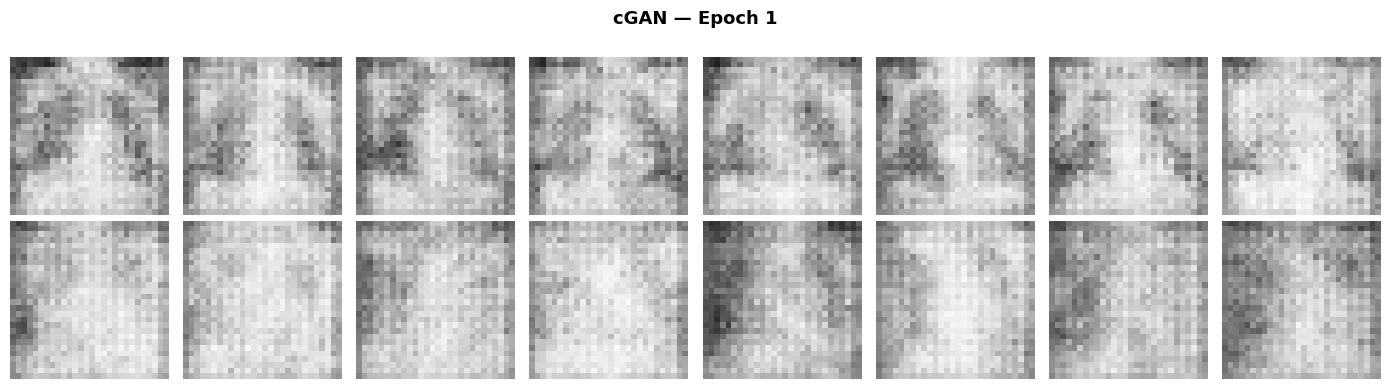

    10 |   1.1413 |   1.1318


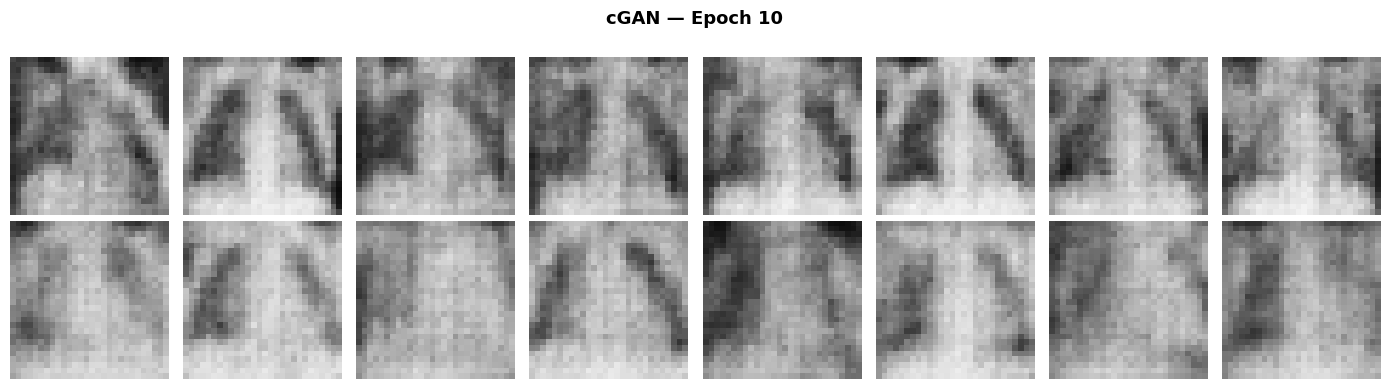

    20 |   1.1584 |   1.1308


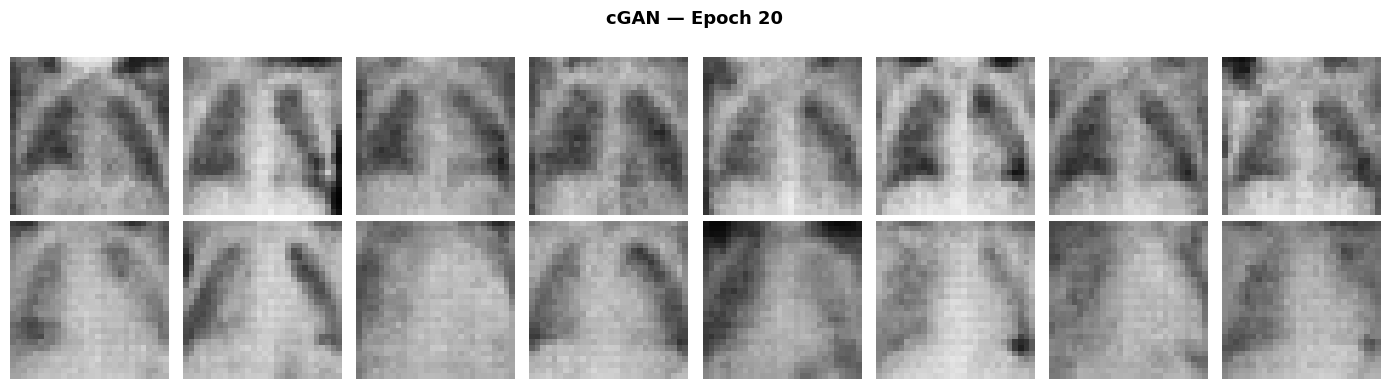

    30 |   1.1643 |   1.1635


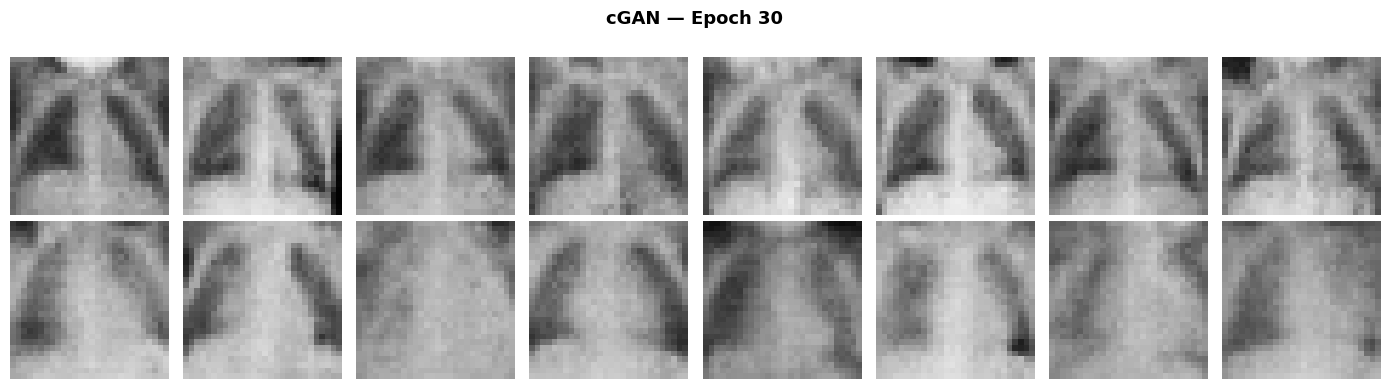

    40 |   1.1651 |   1.1663


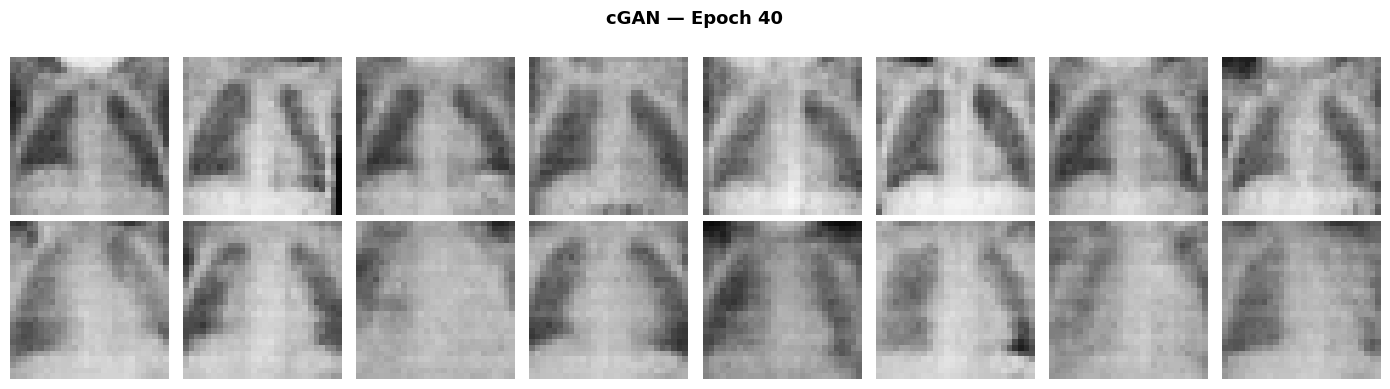

    50 |   1.1357 |   1.1317


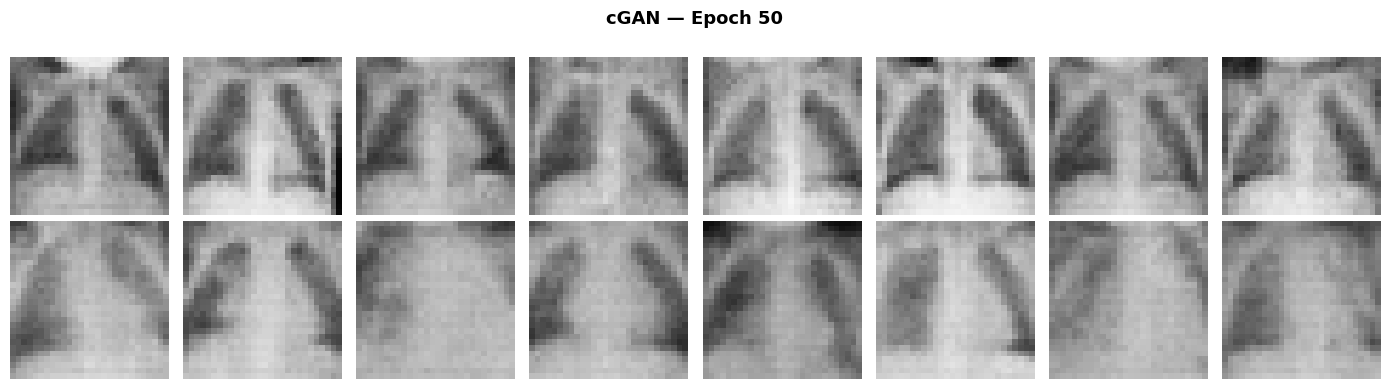

cGAN training complete.


In [ ]:
# ── cGAN Training Loop ────────────────────────────────────────────────────────
# Track per-epoch average losses for plotting later
gan_losses_G, gan_losses_D = [], []

# Smoothing factor: real image targets = 1.0 - 0.1 = 0.9
smooth = GAN_CONFIG['label_smooth']

print('Starting cGAN training...')
print(f"{'Epoch':>6} | {'Loss D':>8} | {'Loss G':>8}")
print('-' * 30)

for epoch in range(1, GAN_CONFIG['epochs'] + 1):
    # Accumulate losses across all batches in this epoch, then average
    epoch_loss_D, epoch_loss_G, n_batches = 0, 0, 0

    for real_imgs, labels in gan_loader:
        B = real_imgs.size(0)  # Actual batch size (last batch may be smaller) #real_imgs have (B,channels,H,W)

        # Move data to GPU/CPU — must match device of model parameters
        real_imgs = real_imgs.to(DEVICE)

        # labels comes as shape (B, 1) from the DataLoader — squeeze removes the
        # extra dimension to get (B,). .long() ensures integer dtype for Embedding.
        labels = labels.squeeze().long().to(DEVICE)

        # Create target tensors for the loss function:
        # Real images get target 0.9 (label smoothing) instead of 1.0 (will lead to D overconfidence and the model could stop learning)
        # Fake images get target 0.0
        # Shape (B, 1) to match D's output shape (B, 1)
        real_targets = torch.full((B, 1), 1.0 - smooth, device=DEVICE)  # 0.9
        fake_targets = torch.zeros(B, 1, device=DEVICE)                  # 0.0

        # ════════════════════════════════════════════════════════════════════
        # STEP 1: Train Discriminator
        # Goal: correctly classify real images as real AND fake images as fake.
        # Loss_D = BCE(D(real), 0.9) + BCE(D(fake), 0.0)
        # ════════════════════════════════════════════════════════════════════

        # Remove gradient accum from the previous batch — PyTorch accumulates by default
        # so that we can calculate new gradient specifc to this batch and then update D weights (gives independent update to D weight)
        opt_D.zero_grad() 

        # Forward real images through D: D should output ~1 for real images
        # BCE compares D's output to target 0.9 (smoothed real label)
        loss_real = criterion(D(real_imgs, labels), real_targets)

        # Generate a batch of fake images from random noise
        # torch.randn samples from N(0,1) — standard normal distribution
        z = torch.randn(B, GAN_CONFIG['latent_dim'], device=DEVICE)

        # .detach() cuts the computational graph between G and D here.
        # When we call loss_D.backward(), gradients should only flow into D,
        # NOT back through the Generator. Without detach(), PyTorch would
        # accumulate gradients in G as a side effect of the D update.
        fake_imgs = G(z, labels).detach()

        # Forward fake images through D: D should output ~0 for fakes
        # D wants to detect fake image and give it a 0 (fake_target = 0)
        loss_fake = criterion(D(fake_imgs, labels), fake_targets)

        # Total discriminator loss is the sum of both terms
        loss_D = loss_real + loss_fake

        # Backpropagation: Compute gradients for D's parameters
        loss_D.backward()

        # Update only D's parameters (opt_G is untouched here)
        opt_D.step()

        # ════════════════════════════════════════════════════════════════════
        # STEP 2: Train Generator
        # Goal: produce images that fool D into outputting ~1 ("this is real").
        # Loss_G = BCE(D(fake), 1.0)  ← G wants D to think fakes are real
        # ════════════════════════════════════════════════════════════════════

        opt_G.zero_grad()

        # Generate a fresh batch of noise — different from the D training noise
        # to introduce more diversity in G's gradient signal
        z = torch.randn(B, GAN_CONFIG['latent_dim'], device=DEVICE)
        fake_imgs = G(z, labels)  # No detach here — gradients must flow into G

        # G wants D to classify its fakes as real → use real_targets (0.9) as target
        # If D outputs 0.1 for a fake, loss is high → G gets large gradient to improve
        # If D outputs 0.9 for a fake, loss is low  → G successfully fooled D
        loss_G = criterion(D(fake_imgs, labels), real_targets)

        # For the same fake images (with noise z): G tries to generate 0.9 real to compete with D which tries to detect 0.0 fake 

        loss_G.backward()  # Gradients flow through D, then through G
        opt_G.step()       # Update only G's parameters

        # Accumulate scalar loss values (.item() extracts the float from a 0-dim tensor)
        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()
        n_batches    += 1

    # Average loss over all batches in this epoch
    avg_D = epoch_loss_D / n_batches
    avg_G = epoch_loss_G / n_batches
    gan_losses_D.append(avg_D)
    gan_losses_G.append(avg_G)

    # Print progress and visualize generated images every 10 epochs
    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6} | {avg_D:>8.4f} | {avg_G:>8.4f}')
        visualize_gan_samples(G, fixed_noise, fixed_labels, epoch)

print('cGAN training complete.')

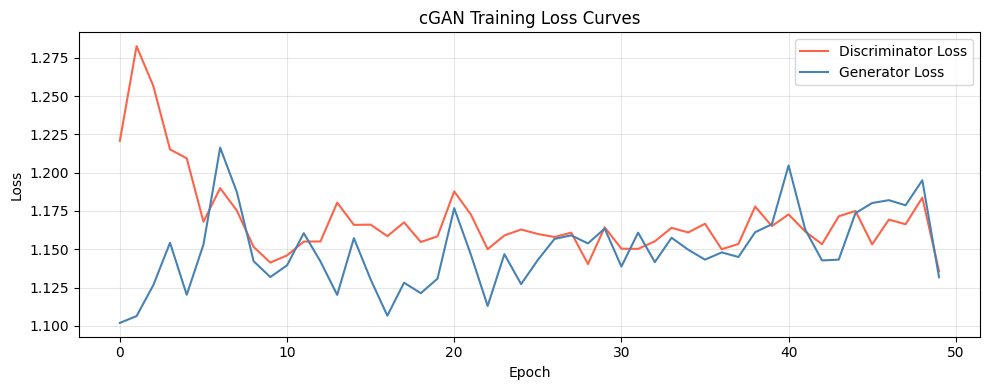

In [16]:
plt.figure(figsize=(10, 4))

# Plot D and G loss curves on the same axis to see the adversarial balance
plt.plot(gan_losses_D, label='Discriminator Loss', color='tomato')
plt.plot(gan_losses_G, label='Generator Loss',     color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('cGAN Training Loss Curves')
plt.legend()
plt.grid(alpha=0.3)  # Faint grid lines for readability
plt.tight_layout()
plt.show()

# ── How to read these curves ──────────────────────────────────────────────────
# Healthy: both losses oscillate without collapsing.
# D loss ≈ 0.69 = random guessing (log(2) ≈ 0.693) — ideal equilibrium point.
#   If D loss → 0: D is too strong, G gets vanishing gradients and stops learning.
#   If D loss → high: G is too strong, D gives random feedback.
# G loss ideally decreases over time as Generator improves at fooling D.

1. D: starts at random => high loss (can't discrim yet)
2. G: starts at random -> garbage image, not good at producing fakes yet -> gets catched easily -> caught => low loss fx
--------------------------------------------------------

This is a healthy training curve overall. Here's what each observation means:

1. Both losses start high then drop quickly (epochs 0–10)


G and D both learning rapidly from random initialization
D loss drops from 1.28 → ~1.15
G loss rises slightly then stabilizes
→ normal early training behaviour
2. Both losses oscillate together after epoch 10

The curves move up and down roughly in sync — this is the adversarial dynamic working as intended:


D gets better → G struggles → G adapts → D struggles → D adapts → repeat
Neither model is dominating the other for long, which is exactly what you want.
3. Both losses converge around 1.15–1.18

This is slightly above the theoretical equilibrium of 0.69 (log 2). This means D is performing slightly better than random guessing but neither model has collapsed:


loss ≈ 0.69  →  perfect equilibrium (D guessing 50/50)
loss ≈ 1.15  →  D slightly better than random, G still competitive
4. No signs of failure modes


No mode collapse:    G loss doesn't drop to 0 while D loss explodes
No D dominance:      D loss doesn't collapse to 0
No divergence:       losses don't trend upward indefinitely

Overall verdict:

The GAN trained stably. The losses haven't fully reached the ideal 0.69 equilibrium, which suggests you could benefit from more epochs or slight hyperparameter tuning (e.g. lower learning rate). But there's no sign of catastrophic failure — the generated images should look reasonably realistic.



---
## Section 4: Conditional VAE (cVAE)

### How it works
- **Encoder** compresses a real image + label into a probability distribution: mean `μ` and log-variance `log σ²`
- **Reparameterization trick**: sample `z = μ + σ·ε` where `ε ~ N(0,1)` — makes sampling differentiable for backprop
- **Decoder** reconstructs the image from `z` + label
- At inference: skip Encoder, sample `z ~ N(0,1)` directly → Decoder → new image

**Loss = Reconstruction (BCE) + β × KL Divergence**
- Reconstruction: how well does Decoder recreate the input image?
- KL: how close is the learned distribution N(μ, σ²) to the prior N(0, I)?

```
real image ──┐
              ├──→ Encoder ──→ μ, σ ──→ z (reparameterize)
label      ──┘                              │
                                            ├──→ Decoder ──→ reconstructed image
                             label ─────────┘
```

In [ ]:
VAE_CONFIG = {
    # latent_dim: size of the latent space z.
    # Unlike the GAN's noise (100-dim), the VAE latent space is structured —
    # it's regularized by KL divergence to follow N(0,I). 64 dims gives
    # enough capacity to represent chest X-ray variation.
    'latent_dim'  : 64,

    # embed_dim: same role as in GAN — label integer → dense vector
    'embed_dim'   : 16,

    'n_classes'   : 2,
    'img_channels': 1,
    'img_size'    : 28,
    'batch_size'  : 128,

    # lr: VAEs can use a higher learning rate than GANs (1e-3 vs 2e-4)
    # because there's no adversarial instability — just a single stable loss.
    'lr'          : 1e-3,

    'epochs'      : 50,

    # beta: weight applied to the KL divergence term in the loss.
    # beta=1.0 → standard VAE (reconstruction and KL are equally weighted)
    # beta>1.0 → β-VAE: encourages more disentangled latent representations
    #            (each latent dimension captures one independent factor of variation)
    #            but may reduce reconstruction quality
    'beta'        : 1.0,
}

In [18]:
class Encoder(nn.Module):
    """
    cVAE Encoder: maps a real image + label → latent distribution parameters (μ, log σ²).

    The encoder does NOT output a single point in latent space.
    It outputs TWO vectors: mu (mean) and log_var (log variance).
    Together they define a Gaussian distribution N(mu, exp(log_var)).
    We sample z from this distribution during training.
    """
    def __init__(self, cfg):
        super().__init__()

        # Same label embedding as in GAN: integer class → dense vector
        self.label_emb = nn.Embedding(cfg['n_classes'], cfg['embed_dim'])

        # Convolutional feature extractor — progressively downsample image
        # while increasing channel depth (classic encoder pattern)
        self.conv = nn.Sequential(
            # (B, 1, 28, 28) → (B, 32, 14, 14): halve spatial, 1→32 channels
            nn.Conv2d(1, 32,  kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),

            # (B, 32, 14, 14) → (B, 64, 7, 7): halve spatial again, 32→64 channels
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),  # Stabilizes training at this deeper layer
            nn.ReLU(inplace=True),

            # (B, 64, 7, 7) → (B, 128, 4, 4): kernel=3,stride=2,pad=1 → floor((7+2-3)/2+1)=4
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )
        # After conv: spatial is 4×4, 128 channels → 128*4*4 = 2048 features

        # Shared FC layer: combines image features with class label
        # Input: 2048 (conv output) + 16 (label embedding) = 2064
        self.fc = nn.Sequential(
            nn.Linear(128 * 4 * 4 + cfg['embed_dim'], 512),
            nn.ReLU(inplace=True)
        )

        # Two separate output heads — both read from the same 512-dim shared representation
        # fc_mu:      outputs the mean vector μ of the latent Gaussian
        # fc_log_var: outputs log(σ²) — using log variance (not σ) for numerical stability
        #             (variance must be positive, but log variance can be any real number)
        self.fc_mu      = nn.Linear(512, cfg['latent_dim'])
        self.fc_log_var = nn.Linear(512, cfg['latent_dim'])

    def forward(self, img, labels):
        # Extract convolutional features and flatten to 1D
        x = self.conv(img)               # (B, 128, 4, 4)
        x = x.view(img.size(0), -1)      # (B, 2048) — flatten spatial dims

        # Get label embedding and fuse with image features
        emb = self.label_emb(labels)     # (B, 16)
        x   = self.fc(torch.cat([x, emb], dim=1))  # (B, 512)

        # Return both distribution parameters — NOT a sampled point
        return self.fc_mu(x), self.fc_log_var(x)   # (B, 64) each

The whole pipeline in one view:


GAN Generator forward():
z(100) + label(16) → concat(116) → FC(6272) → reshape(128,7,7) → ConvTranspose → image(1,28,28)

GAN Discriminator forward():
image(1,28,28) + label_map(1,28,28) → concat(2,28,28) → Conv → flatten → score(1,)

VAE Encoder forward():
image(1,28,28) + label(16) → Conv → flatten(2048) → concat(2064) → FC → mu(64), log_var(64)

VAE Decoder forward():
z(64) + label(16) → concat(80) → FC(2048) → reshape(128,4,4) → ConvTranspose → image(1,28,28)


In [19]:
class Decoder(nn.Module):
    """
    cVAE Decoder: maps a latent point z + label → reconstructed image.

    Mirror of the Encoder — expands back from latent space to image space.
    At generation time: sample z ~ N(0,I) and feed it here directly
    (bypassing the Encoder entirely).
    """
    def __init__(self, cfg):
        super().__init__()

        self.label_emb = nn.Embedding(cfg['n_classes'], cfg['embed_dim'])

        # FC block: project z + label embedding into a 3D feature map
        # Input: 64 (latent_dim) + 16 (embed_dim) = 80
        self.fc = nn.Sequential(
            nn.Linear(cfg['latent_dim'] + cfg['embed_dim'], 512),
            nn.ReLU(inplace=True),
            # Project to the size needed for the first ConvTranspose layer
            # 128 channels × 4×4 spatial = 2048 values
            nn.Linear(512, 128 * 4 * 4),
            nn.ReLU(inplace=True)
        )

        # ConvTranspose upsampling — mirrors the Encoder's downsampling
        self.conv = nn.Sequential(
            # (B, 128, 4, 4) → (B, 64, 7, 7)
            # kernel=3, stride=2, pad=1: output = (4-1)*2 - 2 + 3 = 7
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # (B, 64, 7, 7) → (B, 32, 14, 14)
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # (B, 32, 14, 14) → (B, 1, 28, 28): final output is grayscale
            nn.ConvTranspose2d(32, cfg['img_channels'], kernel_size=4, stride=2, padding=1),

            # Sigmoid maps output to [0,1], matching the [0,1]-normalized training images
            # (VAE transform_vae uses only ToTensor, not the [-1,1] normalization)
            nn.Sigmoid()
        )

    def forward(self, z, labels):
        emb = self.label_emb(labels)                     # (B, 16)
        x   = self.fc(torch.cat([z, emb], dim=1))        # (B, 128*4*4 = 2048)
        x   = x.view(-1, 128, 4, 4)                      # Reshape to 3D feature map
        return self.conv(x)                              # (B, 1, 28, 28) in [0,1]

In [ ]:
def reparameterize(mu, log_var):
    """
    Reparameterization trick — the key innovation that makes VAEs trainable.

    Problem: sampling z ~ N(mu, sigma²) is a random operation.
    Random operations have no gradient — backprop would stop at the sample.

    Solution: rewrite sampling as a deterministic function of a separate
    random variable epsilon ~ N(0,1) that has no learnable parameters:
        z = mu + sigma * epsilon

    Now:
    - epsilon is sampled externally (no gradient needed)
    - mu and sigma are deterministic outputs of the Encoder
    - Gradients flow through mu and sigma normally
    """
    # std = exp(0.5 * log_var) = exp(log(sigma)) = sigma
    # We use log_var instead of var because log_var can be negative (unconstrained),
    # while variance must be positive. exp() ensures positivity.
    std = torch.exp(0.5 * log_var)

    # Sample epsilon from standard normal — same shape as std
    # torch.randn_like creates a tensor of the same shape/dtype/device
    epsilon = torch.randn_like(std)

    # z = mu + sigma * epsilon
    # This is equivalent to sampling from N(mu, sigma²) but is differentiable
    return mu + std * epsilon


def vae_loss(recon_img, real_img, mu, log_var, beta=1.0):
    """
    VAE Loss = Reconstruction Loss + β * KL Divergence

    This is the ELBO (Evidence Lower Bound) — maximizing ELBO is equivalent
    to maximizing the likelihood of the data under the model.

    Reconstruction Loss (BCE): #reconstruction accuracy
        How well does the Decoder recreate the original input?
        Uses binary cross entropy treating each pixel as an independent Bernoulli.
        reduction='sum' sums over all pixels; we then divide by batch size B
        to get a per-image average (not per-pixel, which would be too small).

    KL Divergence: #latent space organisation
        Measures how far the learned latent distribution N(mu, exp(log_var))
        is from the prior N(0, I). Acts as a regularizer:
        - Forces latent codes to stay near the origin (prevents "holes" in latent space)
        - Ensures interpolation between latent points gives valid images
        Closed-form solution: -0.5 * sum(1 + log_var - mu² - exp(log_var))
    """
    B = real_img.size(0)  # Batch size for normalization

    # Reconstruction: pixel-wise BCE between decoder output and original image
    # Both recon_img and real_img are in [0,1] (Sigmoid output, ToTensor input)
    recon_loss = nn.functional.binary_cross_entropy(
        recon_img, real_img, reduction='sum') / B

    # KL divergence between N(mu, var) and N(0,1)
    # The minus sign comes from the ELBO derivation — we minimize loss, so
    # minimizing (-KL) = maximizing KL. The formula below gives a positive value
    # that decreases as the latent distribution approaches N(0,1).
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / B

    # beta scales the trade-off: higher beta = more regularization, less reconstruction detail
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

In [ ]:
# Instantiate Encoder and Decoder and move to device
E   = Encoder(VAE_CONFIG).to(DEVICE)
Dec = Decoder(VAE_CONFIG).to(DEVICE)

# Unlike the GAN which needs two separate optimizers (one per adversary),
# the VAE uses a SINGLE optimizer for both Encoder and Decoder.
# This is because they share one loss (the ELBO) and are updated together.
# list(E.parameters()) + list(Dec.parameters()) passes all parameters to Adam.
opt_VAE = optim.Adam(list(E.parameters()) + list(Dec.parameters()), lr=VAE_CONFIG['lr'])

# ReduceLROnPlateau: automatically reduces learning rate when total loss stops improving.
# patience=5: wait 5 epochs of no improvement before reducing
# factor=0.5: multiply LR by 0.5 (halve it) when triggered
# verbose=True: print a message when LR is reduced
scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt_VAE, patience=5, factor=0.5, verbose=True)

# DataLoader for the [0,1]-normalized dataset (used by VAE)
vae_loader = DataLoader(train_vae, batch_size=VAE_CONFIG['batch_size'],
                        shuffle=True, num_workers=2, pin_memory=True)

# Fixed latent vectors (created once) to track VAE improvement across epochs
# We sample from N(0,I) — this is what we also sample from at generation time
fixed_z_vae = torch.randn(16, VAE_CONFIG['latent_dim']).to(DEVICE) # 16 random latent vectors
fixed_l_vae = torch.tensor([0]*8 + [1]*8).to(DEVICE)  # 8 Normal, 8 Pneumonia

print(f'Encoder params: {sum(p.numel() for p in E.parameters()):,}')
print(f'Decoder params: {sum(p.numel() for p in Dec.parameters()):,}')

Encoder params: 1,230,592
Decoder params: 1,199,425


/opt/anaconda3/envs/bcienv/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [ ]:
def display_comparison(label_val, class_name):
    """Side-by-side comparison: 8 Real / 8 cGAN / 8 cVAE images for one class."""
    real = get_real(train_gan, label_val, n=8)
    gan  = generate_gan(8, label_val)
    vae  = generate_vae(8, label_val)

    # 3 rows x 9 columns: column 0 is a dedicated label column, columns 1-8 are images
    fig, axes = plt.subplots(3, 9, figsize=(15, 6),
                             gridspec_kw={'width_ratios': [0.4, 1,1,1,1,1,1,1,1]})
    fig.suptitle(f'Comparison — Class: {class_name}', fontsize=14, fontweight='bold')

    row_info = [
        (real, 'Real',  'gray'),
        (gan,  'cGAN',  'steelblue'),
        (vae,  'cVAE',  'purple')
    ]

    for row, (imgs, lbl, col) in enumerate(row_info):
        # Column 0: label only, no image
        axes[row, 0].axis('off')
        axes[row, 0].text(0.5, 0.5, lbl,
                          ha='center', va='center',
                          color=col, fontsize=13, fontweight='bold',
                          rotation=90, transform=axes[row, 0].transAxes)

        # Columns 1-8: images
        for c in range(8):
            axes[row, c + 1].imshow(imgs[c].squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
            axes[row, c + 1].axis('off')

    plt.tight_layout()
    plt.show()

display_comparison(0, 'Normal')
display_comparison(1, 'Pneumonia')

okay so the once the training thorugh each batch and epoch is done, the weight is updated (improved), and this weight is used to reconstruct the same 16 image (8 normal and 8 pneumonia) with the same initial noise, to help visualise if the improved weight has resulted in a better image reconstruction?

Epoch 1:
  → train on 37 batches (4708 images) → weights updated 37 times
  → feed fixed_z_vae through Decoder with new weights → visualize 16 images
  → "this is what the Decoder can produce after epoch 1"

Epoch 2:
  → train on 37 batches again → weights updated 37 more times
  → feed SAME fixed_z_vae through Decoder → visualize SAME 16 images
  → "this is what the Decoder can produce after epoch 2"

...

Epoch 50:
  → feed SAME fixed_z_vae → visualize SAME 16 images
  → "this is what the Decoder can produce after full training"


Starting cVAE training...
 Epoch |    Total |    Recon |       KL
----------------------------------------
     1 |   525.86 |   524.53 |     1.34


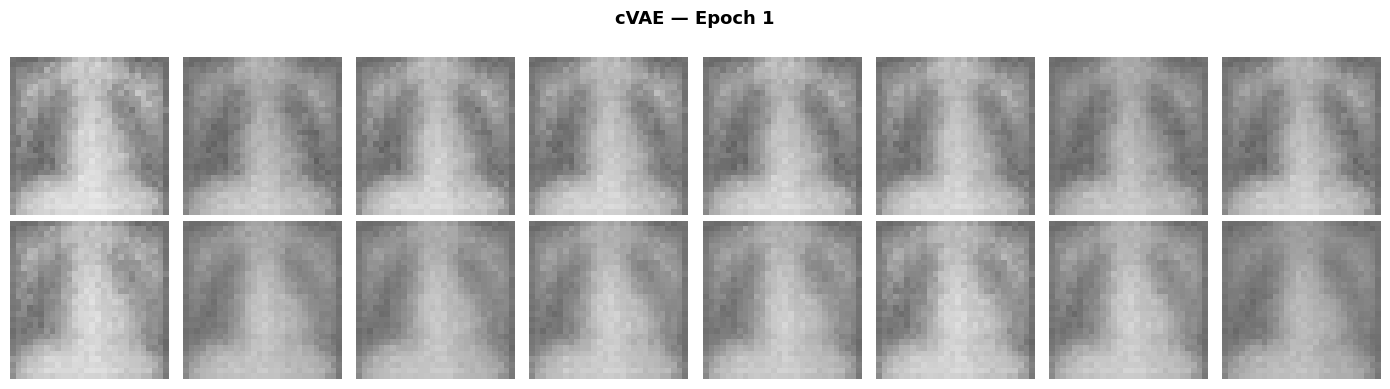

    10 |   506.38 |   504.22 |     2.16


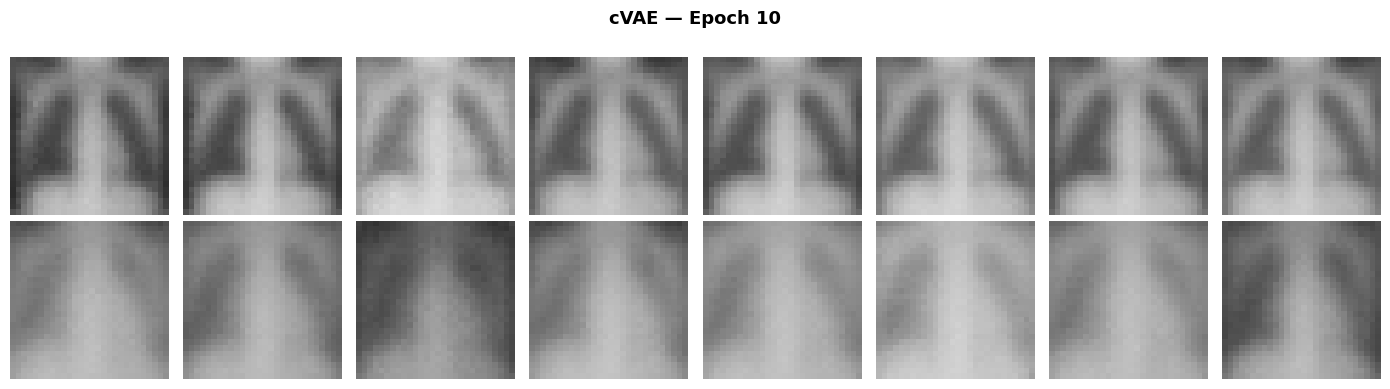

    20 |   505.02 |   502.09 |     2.93


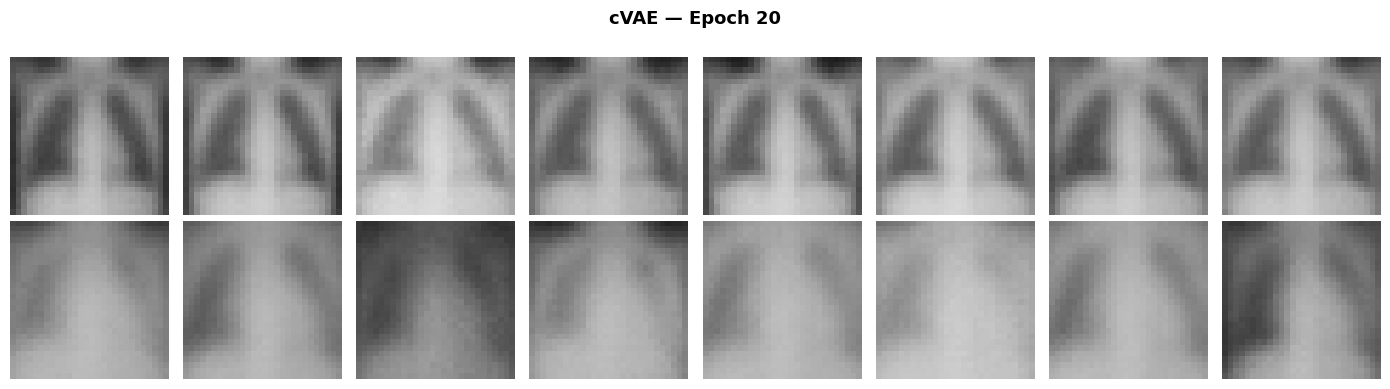

    30 |   504.53 |   501.11 |     3.42


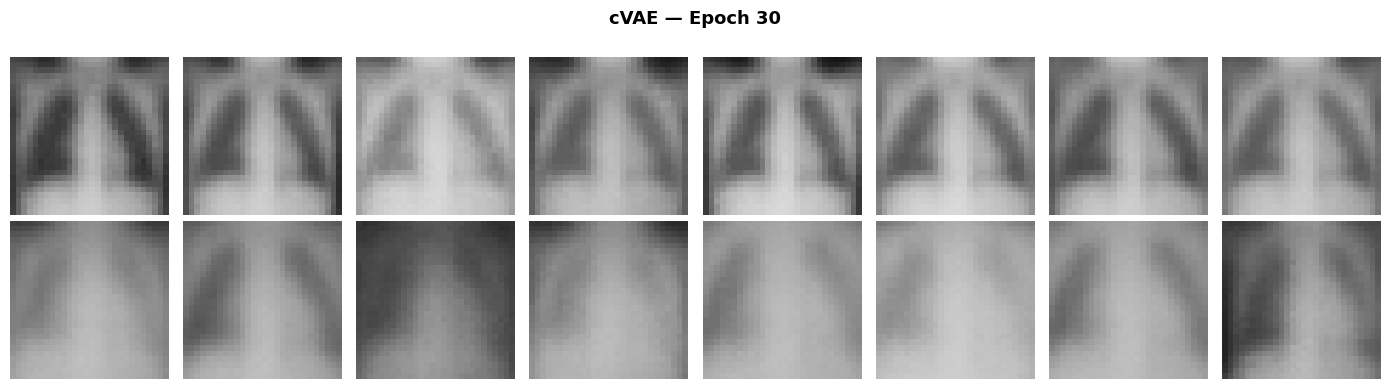

    40 |   504.18 |   500.50 |     3.67


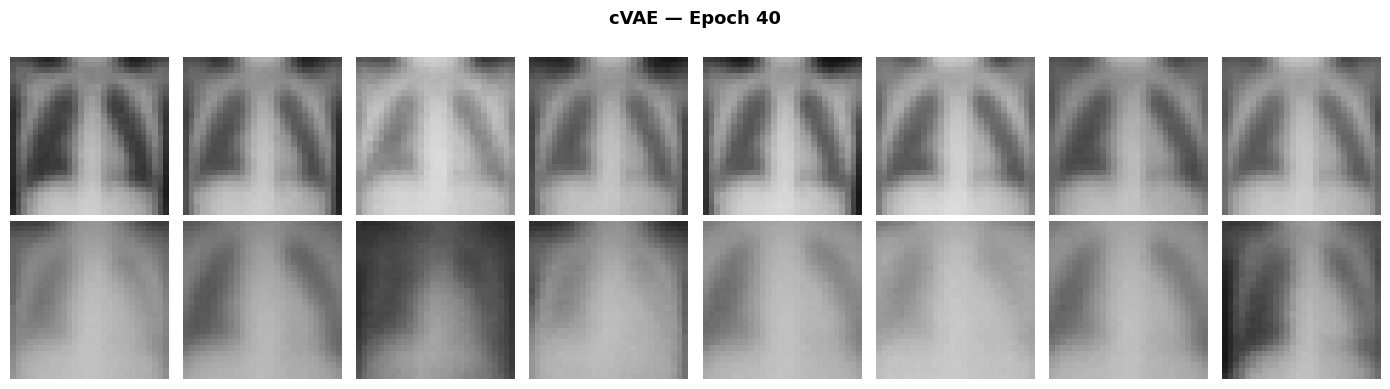

    50 |   503.94 |   500.09 |     3.84


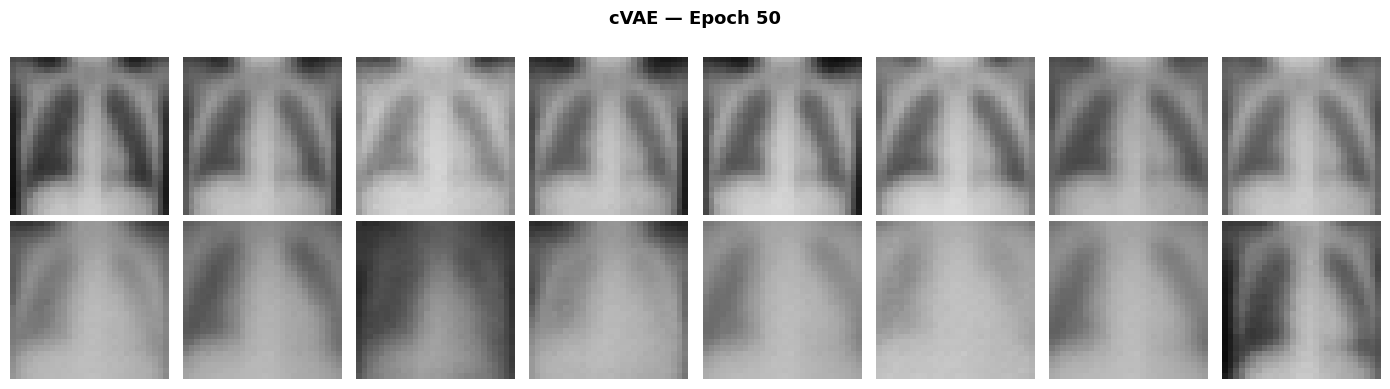

cVAE training complete.


In [23]:
# ── cVAE Training Loop ────────────────────────────────────────────────────────
# Track all three loss components separately for diagnostic plotting
vae_total_losses, vae_recon_losses, vae_kl_losses = [], [], []

print('Starting cVAE training...')
print(f"{'Epoch':>6} | {'Total':>8} | {'Recon':>8} | {'KL':>8}")
print('-' * 40)

for epoch in range(1, VAE_CONFIG['epochs'] + 1):
    # Set both Encoder and Decoder to training mode
    E.train(); Dec.train()
    total_sum, recon_sum, kl_sum, n_batches = 0, 0, 0, 0

    for real_imgs, labels in vae_loader:
        # real_imgs are in [0,1] from transform_vae (ToTensor only)
        real_imgs = real_imgs.to(DEVICE)
        labels    = labels.squeeze().long().to(DEVICE)

        # ── Forward pass through the full VAE ────────────────────────────────

        # 1. Encode: compress image + label into distribution parameters
        #    mu and log_var are both shape (B, latent_dim)
        mu, log_var = E(real_imgs, labels)

        # 2. Sample: draw a latent point z using the reparameterization trick
        #    z is shape (B, latent_dim) — one point per image in the batch
        z = reparameterize(mu, log_var)

        # 3. Decode: reconstruct the image from the sampled latent point
        #    recon_imgs is shape (B, 1, 28, 28) in [0,1]
        recon_imgs = Dec(z, labels)

        # ── Compute loss ──────────────────────────────────────────────────────
        # loss  = total (what we backprop through)
        # recon = reconstruction term (how well Decoder reproduced input)
        # kl    = KL divergence term (how close latent dist is to N(0,I))
        loss, recon, kl = vae_loss(recon_imgs, real_imgs, mu, log_var, VAE_CONFIG['beta'])

        # ── Backward pass ──────────────────────────────────────────────────────
        opt_VAE.zero_grad()  # Clear gradients from previous batch
        loss.backward()      # Compute gradients for ALL VAE parameters (E + Dec)
        opt_VAE.step()       # Update all parameters with Adam

        total_sum += loss.item()
        recon_sum += recon.item()
        kl_sum    += kl.item()
        n_batches += 1

    avg_total = total_sum / n_batches
    avg_recon = recon_sum / n_batches
    avg_kl    = kl_sum    / n_batches

    vae_total_losses.append(avg_total)
    vae_recon_losses.append(avg_recon)
    vae_kl_losses.append(avg_kl)

    # Pass the total loss to the scheduler.
    # If it hasn't improved for 5 epochs, LR will be halved automatically.
    scheduler.step(avg_total)

    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6} | {avg_total:>8.2f} | {avg_recon:>8.2f} | {avg_kl:>8.2f}')
        visualize_vae_samples(Dec, fixed_z_vae, fixed_l_vae, epoch)

print('cVAE training complete.')

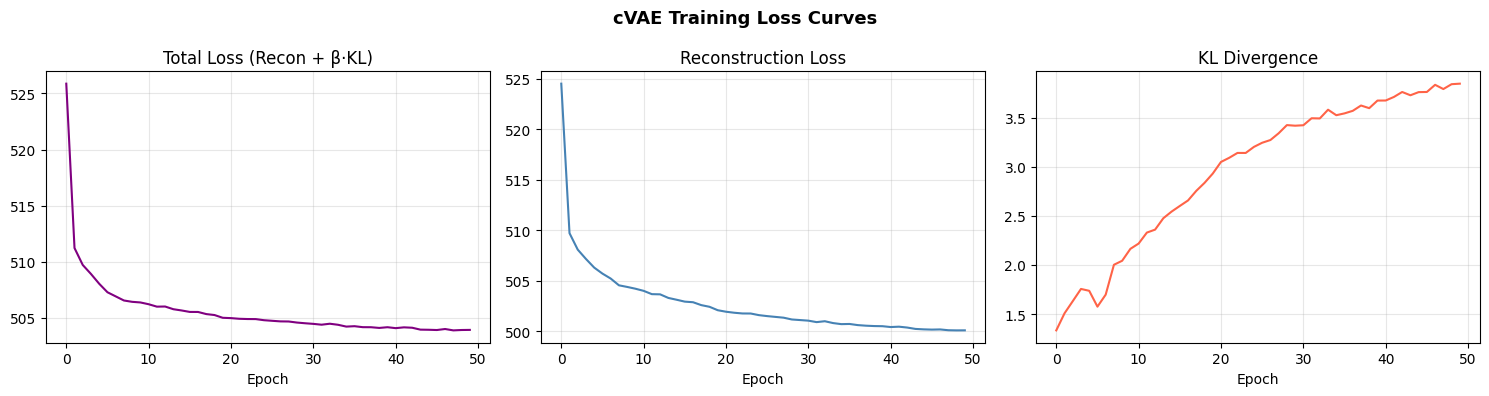

In [24]:
# Three subplots: one per loss component
# Seeing them separately is more informative than one combined curve —
# it lets you diagnose whether reconstruction or KL is the bottleneck.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(vae_total_losses, color='purple')
axes[0].set_title('Total Loss (Recon + β·KL)')
axes[0].set_xlabel('Epoch'); axes[0].grid(alpha=0.3)

axes[1].plot(vae_recon_losses, color='steelblue')
axes[1].set_title('Reconstruction Loss')
axes[1].set_xlabel('Epoch'); axes[1].grid(alpha=0.3)

axes[2].plot(vae_kl_losses, color='tomato')
axes[2].set_title('KL Divergence')
axes[2].set_xlabel('Epoch'); axes[2].grid(alpha=0.3)

plt.suptitle('cVAE Training Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── How to read these curves ──────────────────────────────────────────────────
# Total + Recon loss should decrease steadily — Decoder improving at reconstruction.
# KL loss typically increases initially (latent space "spreading out" to encode
# image variation) then stabilizes (balanced against reconstruction pressure).
# If KL → 0: posterior collapsed to prior, Decoder ignores z (bad — no generation).
# If Recon stays high: Decoder not learning — try lower beta or more epochs.

---
## Section 5: Side-by-side Comparison

We compare:
1. **Visual quality** — do generated images look like real chest X-rays?
2. **Pixel statistics** — mean and std of generated vs. real
3. **FID score** — Fréchet Inception Distance (lower = better)
4. **Latent interpolation** — smooth transitions unique to VAE

In [ ]:
def generate_gan(n=16, label_val=0):
    """Generate n images from the trained cGAN Generator for a given class."""
    G.eval()
    with torch.no_grad():
        # Sample random noise from N(0,I) — the Generator's input
        z  = torch.randn(n, GAN_CONFIG['latent_dim']).to(DEVICE)
        # Create a batch of identical labels (all same class)
        lb = torch.full((n,), label_val, dtype=torch.long, device=DEVICE)
        imgs = G(z, lb).cpu()
    G.train()
    # Denormalize: GAN output is in [-1,1], convert to [0,1] for display and metrics
    return imgs * 0.5 + 0.5

def generate_vae(n=16, label_val=0):
    """Generate n images from the trained cVAE Decoder for a given class."""
    Dec.eval()
    with torch.no_grad():
        # Sample from the prior p(z) = N(0,I) — what the KL term trained the
        # Encoder to match. This is the correct distribution to sample from
        # when generating new images (bypassing the Encoder).
        z  = torch.randn(n, VAE_CONFIG['latent_dim']).to(DEVICE)
        lb = torch.full((n,), label_val, dtype=torch.long, device=DEVICE)
        imgs = Dec(z, lb).cpu()
    Dec.train()
    return imgs  # VAE output is already in [0,1] via Sigmoid

def get_real(dataset, label_val=0, n=16):
    """Fetch n real images of a given class from the GAN-normalized dataset."""
    imgs = []
    for img, label in dataset:
        if int(label) == label_val:
            # Denorm from GAN's [-1,1] back to [0,1] for fair comparison
            imgs.append(img * 0.5 + 0.5)
        if len(imgs) == n:
            break
    return torch.stack(imgs)  # Stack list of tensors into a single (n,1,28,28) tensor

/var/folders/5d/k7gxx1wn7y156f92kp762f700000gn/T/ipykernel_94944/569171838.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if int(label) == label_val:


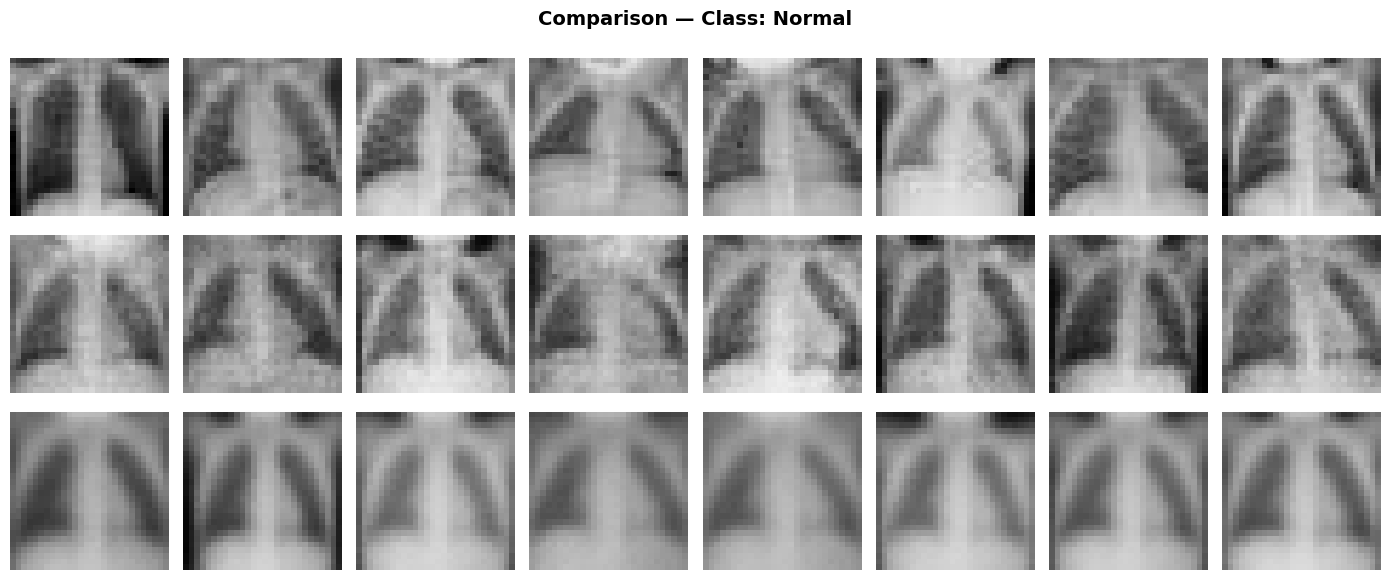

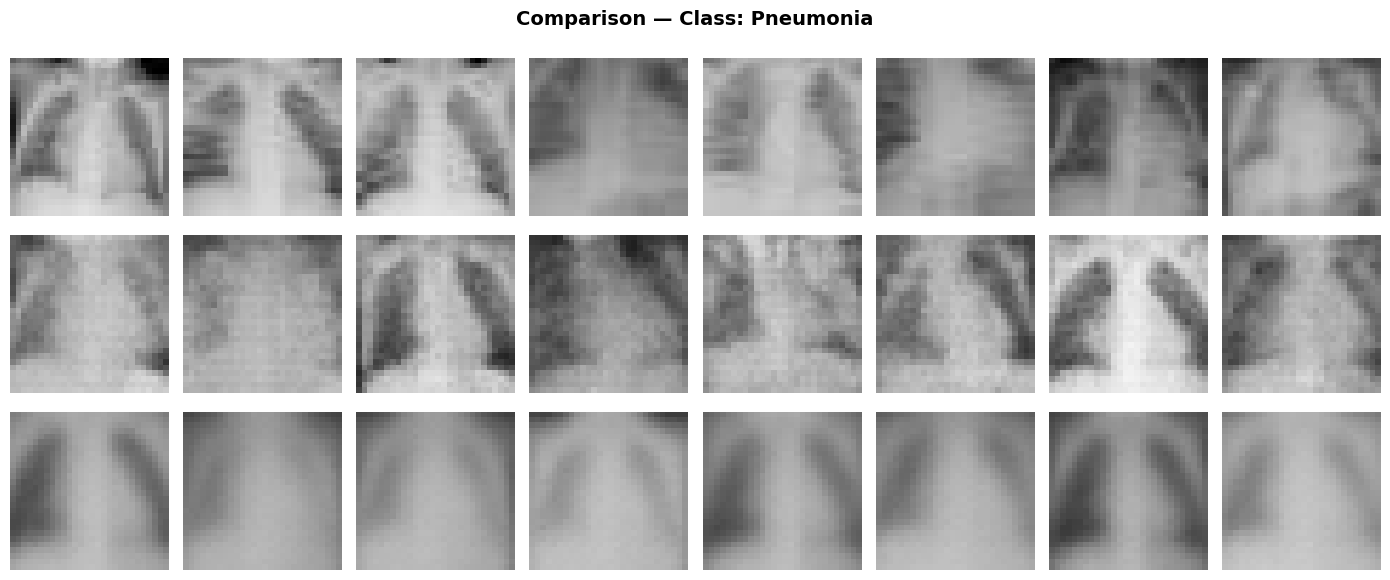

In [34]:
def display_comparison(label_val, class_name):
    """Side-by-side comparison: 8 Real / 8 cGAN / 8 cVAE images for one class."""
    real = get_real(train_gan, label_val, n=8)
    gan  = generate_gan(8, label_val)
    vae  = generate_vae(8, label_val)

    # 3 rows (Real, cGAN, cVAE) × 8 columns
    fig, axes = plt.subplots(3, 8, figsize=(14, 6))
    fig.suptitle(f'Comparison — Class: {class_name}', fontsize=14, fontweight='bold')

    # Zip rows with their image batches, row labels, and colors
    for row, (imgs, lbl, col) in enumerate([
        (real, 'Real',  'gray'),
        (gan,  'cGAN',  'steelblue'),
        (vae,  'cVAE',  'purple')
    ]):
        for c in range(8):
            # .squeeze() removes channel dim for imshow: (1,28,28) → (28,28)
            axes[row, c].imshow(imgs[c].squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
            axes[row, c].axis('off')
        # Add row label on leftmost column only, rotated vertically
        axes[row, 0].set_ylabel(lbl, color=col, fontsize=11, rotation=90, labelpad=10)

    plt.tight_layout()
    plt.show()

# Run comparison for both classes
display_comparison(0, 'Normal')
display_comparison(1, 'Pneumonia')

In [27]:
# ── Pixel Statistics Comparison ───────────────────────────────────────────────
# Mean: average brightness. If generated images are much brighter/darker than
# real ones, the model hasn't captured the correct intensity distribution.
# Std: spread of pixel values. Low std = images are too uniform (blurry/flat).

print(f"{'Class':<12} {'Source':<8} {'Mean':>8} {'Std':>8}")
print('-' * 40)

for label_val, class_name in [(0, 'Normal'), (1, 'Pneumonia')]:
    # Use 256 samples for a stable statistical estimate
    real = get_real(train_gan, label_val, n=256)
    gan  = generate_gan(256, label_val)
    vae  = generate_vae(256, label_val)

    for source, imgs in [('Real', real), ('cGAN', gan), ('cVAE', vae)]:
        # .mean() and .std() average over ALL pixels across ALL 256 images
        print(f"{class_name:<12} {source:<8} {imgs.mean():>8.4f} {imgs.std():>8.4f}")
    print()  # Blank line between classes

Class        Source       Mean      Std
----------------------------------------


/var/folders/5d/k7gxx1wn7y156f92kp762f700000gn/T/ipykernel_94944/569171838.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if int(label) == label_val:


Normal       Real       0.5521   0.1842
Normal       cGAN       0.5548   0.1905
Normal       cVAE       0.5436   0.1579

Pneumonia    Real       0.5733   0.1600
Pneumonia    cGAN       0.5932   0.1674
Pneumonia    cVAE       0.5810   0.1322



In [28]:
# ── FID Score (Pixel-space approximation) ─────────────────────────────────────
# FID (Fréchet Inception Distance) quantifies how similar two image distributions are.
#
# Standard FID extracts features from the Inception-v3 network, but that network
# expects 299×299 RGB images. Since our images are 28×28 grayscale, we use
# raw pixel vectors instead — this gives a pixel-space FID, not a feature-space FID.
# It's less perceptually calibrated but still useful for relative comparison.
#
# Formula: FID = ||μ_r - μ_g||² + Tr(Σ_r + Σ_g - 2*(Σ_r·Σ_g)^0.5)
# where μ_r, Σ_r = mean and covariance of real image pixels
#       μ_g, Σ_g = mean and covariance of generated image pixels
# Lower FID = generated distribution is closer to real.

def compute_fid(real_imgs, gen_imgs):
    # Flatten each image to a 1D pixel vector: (N, 1, 28, 28) → (N, 784)
    # Each row is one image; each column is one pixel position
    real_flat = real_imgs.view(real_imgs.size(0), -1).numpy()
    gen_flat  = gen_imgs.view(gen_imgs.size(0),  -1).numpy()

    # Compute mean vector (784-dim) and covariance matrix (784×784) for each set
    # np.cov(X, rowvar=False): each column is a variable (pixel), each row is a sample
    mu_r, sigma_r = real_flat.mean(0), np.cov(real_flat, rowvar=False)
    mu_g, sigma_g = gen_flat.mean(0),  np.cov(gen_flat,  rowvar=False)

    # Squared L2 distance between means: captures differences in average pixel values
    diff = mu_r - mu_g

    # Matrix square root of the product of covariance matrices
    # linalg.sqrtm computes A^0.5 such that A^0.5 @ A^0.5 = A
    cov_mean = linalg.sqrtm(sigma_r @ sigma_g)

    # Due to floating-point errors, the sqrt may produce tiny imaginary components.
    # Taking .real discards them — safe since the true result is always real.
    if np.iscomplexobj(cov_mean):
        cov_mean = cov_mean.real

    # FID = ||mu_r - mu_g||² + Tr(Σ_r + Σ_g - 2*sqrt(Σ_r·Σ_g))
    # np.trace sums the diagonal elements of the matrix
    return float(diff @ diff + np.trace(sigma_r + sigma_g - 2 * cov_mean))


print('Computing FID scores...')
print(f"{'Class':<12} {'cGAN FID':>12} {'cVAE FID':>12}")
print('-' * 38)

for label_val, class_name in [(0, 'Normal'), (1, 'Pneumonia')]:
    real    = get_real(train_gan, label_val, n=256)
    fid_gan = compute_fid(real, generate_gan(256, label_val))
    fid_vae = compute_fid(real, generate_vae(256, label_val))
    print(f"{class_name:<12} {fid_gan:>12.2f} {fid_vae:>12.2f}")

print()
print('Lower FID = generated distribution closer to real.')
print('cGAN typically lower (sharper), cVAE more stable to train.')

Computing FID scores...
Class            cGAN FID     cVAE FID
--------------------------------------


/var/folders/5d/k7gxx1wn7y156f92kp762f700000gn/T/ipykernel_94944/569171838.py:31: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  if int(label) == label_val:


Normal               2.72         4.57
Pneumonia            1.65         3.46

Lower FID = generated distribution closer to real.
cGAN typically lower (sharper), cVAE more stable to train.


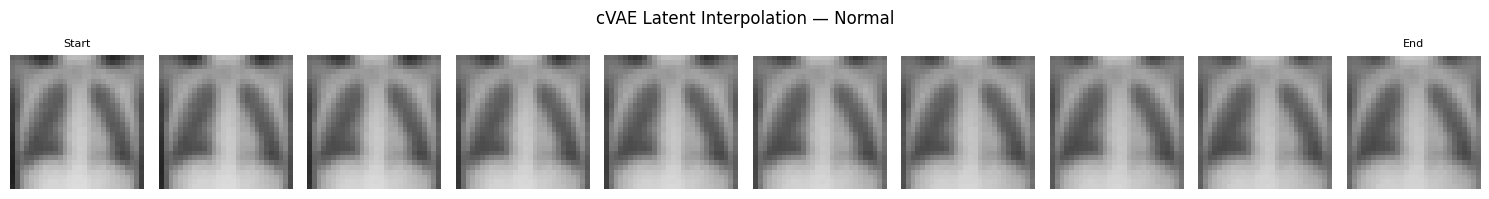

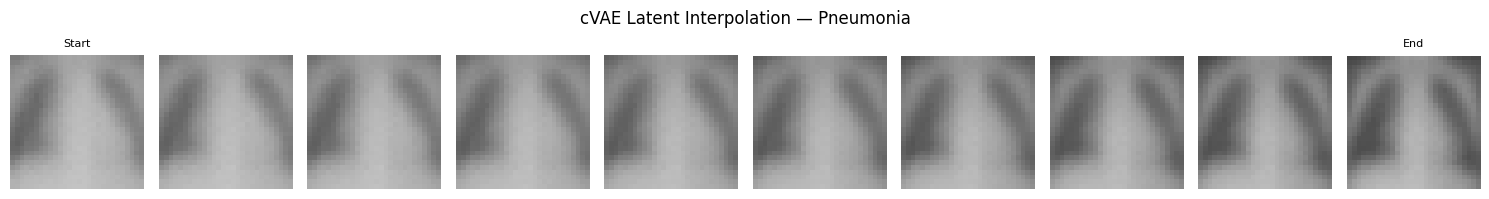

In [29]:
# ── VAE Latent Interpolation ──────────────────────────────────────────────────
# A key advantage of VAEs over GANs: the latent space is smooth and structured.
#
# Because the KL term forces the encoder to map images to a region near N(0,I),
# the latent space is well-filled with no "holes". Any point in it decodes to
# a plausible image. GANs don't have this guarantee — random interpolations
# in GAN latent space can produce artifacts.
#
# Here we linearly interpolate between two random z vectors:
# z(alpha) = (1-alpha)*z_a + alpha*z_b, alpha in [0, 1]
# and decode each intermediate point to see how images transition.

def latent_interpolation(decoder, label_val, steps=10):
    decoder.eval()
    with torch.no_grad():
        # Two random starting points in latent space
        z_a   = torch.randn(1, VAE_CONFIG['latent_dim']).to(DEVICE)
        z_b   = torch.randn(1, VAE_CONFIG['latent_dim']).to(DEVICE)
        label = torch.tensor([label_val], device=DEVICE)

        # np.linspace(0, 1, steps): evenly spaced alpha values from 0 to 1
        # For each alpha, compute the interpolated z and decode it
        imgs = [decoder((1 - a) * z_a + a * z_b, label).cpu()
                for a in np.linspace(0, 1, steps)]

    class_name = 'Normal' if label_val == 0 else 'Pneumonia'
    fig, axes  = plt.subplots(1, steps, figsize=(steps * 1.5, 2))
    fig.suptitle(f'cVAE Latent Interpolation — {class_name}', fontsize=12)

    for i, img in enumerate(imgs):
        # img is (1, 1, 28, 28) — squeeze removes both batch and channel dims
        axes[i].imshow(img.squeeze().numpy(), cmap='gray', vmin=0, vmax=1)
        axes[i].axis('off')
        # Only label the first and last columns
        if i == 0:        axes[i].set_title('Start', fontsize=8)
        if i == steps-1:  axes[i].set_title('End',   fontsize=8)

    plt.tight_layout()
    plt.show()

latent_interpolation(Dec, label_val=0)  # Interpolate between two Normal images
latent_interpolation(Dec, label_val=1)  # Interpolate between two Pneumonia images

In [30]:
# ── Summary Table ─────────────────────────────────────────────────────────────
rows = [
    ('Output sharpness',   'High (adversarial)',     'Medium (blurrier)'),
    ('Training stability', 'Unstable (D/G balance)', 'Stable (single loss)'),
    ('Training time',      'Slower',                 'Faster'),
    ('Mode collapse risk', 'Yes (common)',            'No'),
    ('Latent space',       'Unstructured',            'Smooth & continuous'),
    ('Loss type',          'Two adversarial losses',  'One ELBO loss'),
    ('Best for',           'High-fidelity synthesis', 'Interpolation, diversity'),
]

print(f"{'Attribute':<22} {'cGAN':<28} {'cVAE'}")
print('=' * 72)
for attr, gan_val, vae_val in rows:
    print(f"{attr:<22} {gan_val:<28} {vae_val}")

Attribute              cGAN                         cVAE
Output sharpness       High (adversarial)           Medium (blurrier)
Training stability     Unstable (D/G balance)       Stable (single loss)
Training time          Slower                       Faster
Mode collapse risk     Yes (common)                 No
Latent space           Unstructured                 Smooth & continuous
Loss type              Two adversarial losses       One ELBO loss
Best for               High-fidelity synthesis      Interpolation, diversity
